# H-013 · Vol-aware entry k_t vs S1 vol targeting

Arms: `fixed_k` | `kt` (`k_t = 2 * σ_t / σ_bar`) | `s1_vt` (`risk.analytics.s1_equities.vol_targeting`).

Type `VOL_STAR`.


## 0. Imports & Config


In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s2_coint.report import (
    arm_selection_table,
    fold_table,
    fold_val_metrics,
    full_is_metrics,
    load_star_stack,
    median_sharpe_hint,
    plot_fold_boxplots,
    require_star,
    save_star_stack,
    write_tearsheet_pdf,
)
from backtest.s2_coint.research import (
    ARTIFACTS_DIR,
    DEFAULT_STAR_STACK,
    config_from_stack,
    is_end_for_stack,
    load_s1_weekly,
    frozen_pairs_for_universe,
    load_universe_panels,
    lookbacks_for_bar,
    overlay_kalman_hedge,
    overlay_ols_hedge,
    n_trials_local,
    n_trials_stack,
    register_hypothesis_arms,
    repo_root,
    split_is_oos,
    tearsheet_path,
)
from backtest.s2_coint.runner import run_s2_backtest
from backtest.s2_coint.walkforward import embargo_bars_for_config, make_s2_folds
from strategies.s2_coint.config import S2SimConfig

STAR_PATH = DEFAULT_STAR_STACK
TEARSHEET_DIR = ARTIFACTS_DIR
stack = load_star_stack(STAR_PATH)
# Universe from H-001. PAIRS_STAR is only populated when BOOK_STAR = freeze (H-004);
# otherwise fall back to the ranked frozen book written by H-001.
require_star("UNIVERSE_STAR", stack.get("UNIVERSE_STAR"))
UNIVERSE = str(stack["UNIVERSE_STAR"])
PAIRS_STAR = list(stack.get("PAIRS_STAR") or frozen_pairs_for_universe(UNIVERSE, "1d", root=ROOT))
print("stack keys:", sorted(stack))
print("UNIVERSE", UNIVERSE, "PAIRS", PAIRS_STAR)


stack keys: ['ADF_WINDOW_STAR', 'ATR_EXIT_STAR', 'BAR_STAR', 'BOOK_STAR', 'BREAK_STAR', 'CORR_GATE_STAR', 'ENTRY_STAR', 'ENTRY_Z_STAR', 'HEDGE_STAR', 'HL_EXIT_STAR', 'HL_GATE_STAR', 'KALMAN_DELTA_STAR', 'OLS_WINDOW_STAR', 'OVERLAP_STAR', 'PAIRS_STAR', 'PAIR_MAX_LOSS_STAR', 'RESEARCH_IS_END_STAR', 'SIZE_STAR', 'TREND_STAR', 'UNIVERSE_STAR', 'VOL_STAR', 'VT_TARGET_ANN_VOL_STAR', 'VT_TARGET_PICK_STAR', 'VT_TARGET_SOURCE_STAR', 'VT_TARGET_WRITTEN_AT_STAR', 'Z_WINDOW_MODE_STAR', 'Z_WINDOW_STAR']
UNIVERSE D PAIRS ['WSO|WSO.B', 'HEI|HEI.A', 'NWS|NWSA']


## 1. Load frozen panel / PAIRS_STAR


In [2]:
require_star("BAR_STAR", stack.get("BAR_STAR"))
BAR = str(stack["BAR_STAR"])
train, full = load_universe_panels(UNIVERSE, BAR, PAIRS_STAR, root=ROOT)
lb = lookbacks_for_bar(
    BAR,
    ols_days=int(stack["OLS_WINDOW_STAR"]) if stack.get("OLS_WINDOW_STAR") not in (None, "") else None,
    z_days=int(stack["Z_WINDOW_STAR"]) if stack.get("Z_WINDOW_STAR") not in (None, "") else None,
    adf_days=int(stack["ADF_WINDOW_STAR"]) if stack.get("ADF_WINDOW_STAR") not in (None, "") else None,
)
train = overlay_ols_hedge(
    train,
    ols_window=lb["ols_window"],
    z_window=lb["z_window"],
    hl_window=lb["hl_window"],
    adf_window=lb["adf_window"],
)
full = overlay_ols_hedge(
    full,
    ols_window=lb["ols_window"],
    z_window=lb["z_window"],
    hl_window=lb["hl_window"],
    adf_window=lb["adf_window"],
)
if stack.get("HEDGE_STAR") == "kalman":
    kf_delta = stack["KALMAN_DELTA_STAR"]
    train = overlay_kalman_hedge(
        train,
        burn_in=lb["kalman_burn_in"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        adf_window=lb["adf_window"],
        delta=kf_delta,
    )
    full = overlay_kalman_hedge(
        full,
        burn_in=lb["kalman_burn_in"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        adf_window=lb["adf_window"],
        delta=kf_delta,
    )

is_end = is_end_for_stack(stack, full if BAR == "1h" else train)
if BAR == "1d":
    is_panel, oos_panel = train.copy(), full.loc[pd.to_datetime(full["date"]) > is_end].copy()
else:
    is_panel, oos_panel = split_is_oos(full, is_end=is_end)
s1_weekly = load_s1_weekly(ROOT)
print("bar", BAR, "is_end", is_end, "IS rows", len(is_panel), "OOS rows", len(oos_panel))
is_panel.head()


bar 1d is_end 2021-12-31 00:00:00 IS rows 8113 OOS rows 2346


,date,pair_id,ticker_y,ticker_x,open_y,high_y,low_y,close_y,open_x,high_x,low_x,close_x,alpha,beta,spread,z,half_life,adf_pvalue,variance_jump
0,1998-04-27,HEI|HEI.A,HEI,HEI.A,4.726864,4.726864,4.608692,4.726864,4.648083,4.648083,4.569302,4.588997,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1998-04-28,HEI|HEI.A,HEI,HEI.A,4.726864,4.785950,4.726864,4.785950,4.588997,4.588997,4.529911,4.569302,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1998-04-29,HEI|HEI.A,HEI,HEI.A,4.785950,4.864731,4.785950,4.864731,4.549607,4.549607,4.510216,4.510216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1998-04-30,HEI|HEI.A,HEI,HEI.A,4.904121,4.982902,4.894274,4.982902,4.490521,4.510216,4.431435,4.451130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1998-05-01,HEI|HEI.A,HEI,HEI.A,4.923817,5.140465,4.923817,5.140465,4.411740,4.490521,4.411740,4.451130,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Attach this-hyp columns


In [3]:
panel = is_panel.copy()
print(panel.columns.tolist())
panel.head()


['date', 'pair_id', 'ticker_y', 'ticker_x', 'open_y', 'high_y', 'low_y', 'close_y', 'open_x', 'high_x', 'low_x', 'close_x', 'alpha', 'beta', 'spread', 'z', 'half_life', 'adf_pvalue', 'variance_jump']


,date,pair_id,ticker_y,ticker_x,open_y,high_y,low_y,close_y,open_x,high_x,low_x,close_x,alpha,beta,spread,z,half_life,adf_pvalue,variance_jump
0,1998-04-27,HEI|HEI.A,HEI,HEI.A,4.726864,4.726864,4.608692,4.726864,4.648083,4.648083,4.569302,4.588997,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1998-04-28,HEI|HEI.A,HEI,HEI.A,4.726864,4.785950,4.726864,4.785950,4.588997,4.588997,4.529911,4.569302,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1998-04-29,HEI|HEI.A,HEI,HEI.A,4.785950,4.864731,4.785950,4.864731,4.549607,4.549607,4.510216,4.510216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1998-04-30,HEI|HEI.A,HEI,HEI.A,4.904121,4.982902,4.894274,4.982902,4.490521,4.510216,4.431435,4.451130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1998-05-01,HEI|HEI.A,HEI,HEI.A,4.923817,5.140465,4.923817,5.140465,4.411740,4.490521,4.411740,4.451130,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Walk-forward folds


In [4]:
dates = pd.DatetimeIndex(pd.to_datetime(panel["date"])).sort_values().unique()
folds = make_s2_folds(dates, n_folds=3, embargo_bars=embargo_bars_for_config(bar=BAR))
fold_table(folds)


,fold_id,train_start,train_end,n_train,embargo_start,embargo_end,val_start,val_end,n_val
0,1,1998-04-27,2004-03-22,1485,2004-03-23,2004-03-29,2004-03-30,2010-03-02,1491
1,2,1998-04-27,2010-02-23,2976,2010-02-24,2010-03-02,2010-03-03,2016-02-01,1490
2,3,1998-04-27,2016-01-25,4466,2016-01-26,2016-02-01,2016-02-02,2021-12-31,1491


## 4. Fold-val metrics (validation only)


In [5]:
base = config_from_stack(stack)
configs = {
    "fixed_k": config_from_stack(stack, vol_mode="fixed_k"),
    "kt": config_from_stack(stack, vol_mode="kt"),
    "s1_vt": config_from_stack(stack, vol_mode="s1_vt"),
}
HYP_ID = "H-013"
register_hypothesis_arms(HYP_ID, list(configs.keys()), overwrite=True)
fold_df = fold_val_metrics(panel, folds, configs, hyp_id=HYP_ID, s1_weekly=s1_weekly)
full_is_df = full_is_metrics(panel, configs, hyp_id=HYP_ID, s1_weekly=s1_weekly)
fold_df


,arm,fold_id,ann_sharpe,max_drawdown,corr_to_s1,psr,dsr_local,dsr_stack,n_trials_local,n_trials_stack,n_days,n_entries,pct_z_finite,median_hl_bars,median_hl_sessions
0,fixed_k,1,0.463343,-0.085436,NaN,9.152446e-10,1.0,0.999997,3,47,1491,12,1.00000,11.086695,11.086695
1,fixed_k,2,-0.367191,-0.060730,-0.036345,0.000000e+00,0.0,0.000000,3,47,1490,9,0.84186,12.978339,12.978339
2,fixed_k,3,0.485668,-0.019895,0.202522,5.168300e-09,1.0,0.999999,3,47,1491,36,1.00000,9.775787,9.775787
3,kt,1,0.242930,-0.090247,NaN,0.000000e+00,1.0,0.999987,3,47,1491,26,1.00000,11.086695,11.086695
4,kt,2,-0.424536,-0.063221,-0.103102,0.000000e+00,0.0,0.000000,3,47,1490,40,0.84186,12.978339,12.978339
5,kt,3,-0.696122,-0.102653,0.109952,0.000000e+00,0.0,0.000000,3,47,1491,131,1.00000,9.775787,9.775787
6,s1_vt,1,0.359688,-0.029805,NaN,0.000000e+00,1.0,1.000000,3,47,1491,12,1.00000,11.086695,11.086695
7,s1_vt,2,-0.429067,-0.045768,-0.036345,0.000000e+00,0.0,0.000000,3,47,1490,9,0.84186,12.978339,12.978339
8,s1_vt,3,0.447137,-0.022325,0.207251,0.000000e+00,1.0,1.000000,3,47,1491,36,1.00000,9.775787,9.775787


## 5. Boxplots (do not assign STAR here)


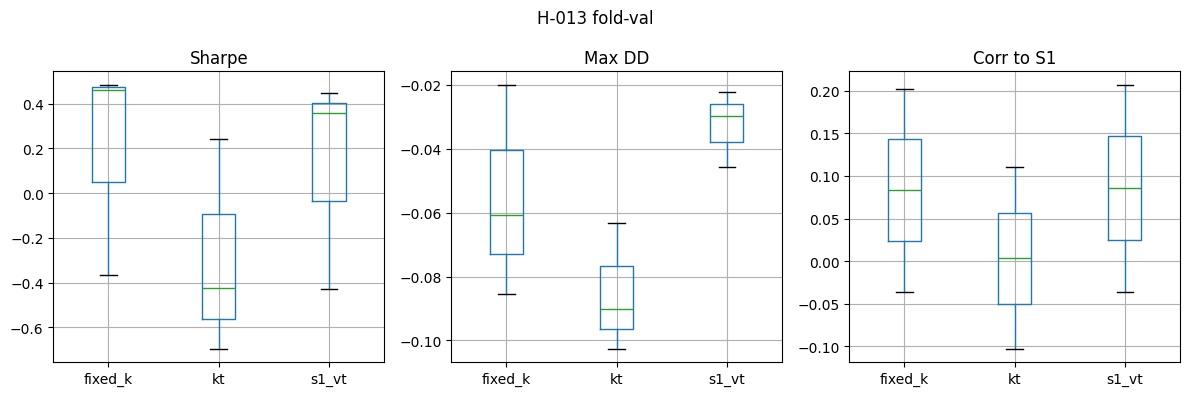

median-Sharpe hint (commentary only): fixed_k


,arm,median_val_sharpe,full_is_sharpe,max_drawdown,corr_to_s1,n_folds,median_psr,median_dsr_local,median_dsr_stack,full_is_psr,full_is_dsr_local,full_is_dsr_stack
0,fixed_k,0.463343,0.387896,-0.060730,0.083088,3,9.152446e-10,1.0,0.999997,0.0,1.000000e+00,1.000000e+00
1,kt,-0.424536,-0.070023,-0.090247,0.003425,3,0.000000e+00,0.0,0.000000,0.0,4.020282e-09,8.483769e-13
2,s1_vt,0.359688,0.354987,-0.029805,0.085453,3,0.000000e+00,1.0,1.000000,0.0,1.000000e+00,1.000000e+00


In [6]:
plot_fold_boxplots(fold_df, title="H-013 fold-val")
plt.show()
print("median-Sharpe hint (commentary only):", median_sharpe_hint(fold_df))
display(arm_selection_table(fold_df, full_is_df))


## 6. Type `VOL_STAR` then save


In [7]:
VOL_STAR = "s1_vt"  # TODO set after review — do not use argmax / median Sharpe
require_star("VOL_STAR", VOL_STAR)
stack["VOL_STAR"] = VOL_STAR
save_star_stack(STAR_PATH, stack)
print("wrote", STAR_PATH)


wrote C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s2_coint\artifacts\s2_star_stack.json


## 7. Sealed OOS once


In [8]:
require_star("VOL_STAR", VOL_STAR)
oos_cfg = config_from_stack(load_star_stack(STAR_PATH))
n_loc = n_trials_local(configs)
n_stk = n_trials_stack(HYP_ID, configs)
oos = run_s2_backtest(
    oos_panel, oos_cfg, s1_weekly=s1_weekly,
    n_trials_local=n_loc,
    n_trials_stack=n_stk,
)

print(oos.metrics)
write_tearsheet_pdf(
    tearsheet_path("H-013", str(VOL_STAR)), oos.returns, title="H-013 sealed OOS",
    n_trials_local=n_loc,
    n_trials_stack=n_stk,
)

print("tearsheet", tearsheet_path("H-013", str(VOL_STAR)))


{'ann_sharpe': -0.238819894448841, 'max_drawdown': -0.05151857675790472, 'n_days': 1173, 'psr': 0.0, 'dsr_local': 6.661338147750939e-16, 'dsr_stack': 0.0, 'skew': -1.2664692665957185, 'excess_kurtosis': 38.56402343107303, 'n_trials_local': 3, 'n_trials_stack': 47, 'corr_to_s1': -0.025295428316690453}
tearsheet C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s2_coint\artifacts\H-013_s1_vt.pdf


## 8. Notes for next hyp


H-014 adaptive z-window is next (fixed 60 vs clip 20–120 vs alt 10–252).
